# Task 06 – Model Evaluation

Evaluates the three tuned models from Task 5 on the held-out test set using multi-class metrics, and identifies the best-performing model.

In [2]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

# Load the models and the exact train/test split used in Task 5
lr = joblib.load('../models/logistic_regression.pkl')
rf = joblib.load('../models/random_forest.pkl')
xgb = joblib.load('../models/xgboost_model.pkl')
split = joblib.load('../models/train_test_split.pkl')

X_test, y_test, y_test_num = split['X_test'], split['y_test'], split['y_test_num']
risk_map = split['risk_map']
inv_risk_map = {v: k for k, v in risk_map.items()}
class_order = ['Low', 'Medium', 'High']

## Metrics per model

For a multi-class target, we report **macro-averaged** precision/recall/F1 (each class weighted equally) so that the minority `Low` class isn't drowned out by `Medium`/`High`.

In [3]:
results = []

for name, model, uses_numeric in [('Logistic Regression', lr, False),
                                    ('Random Forest', rf, False),
                                    ('XGBoost', xgb, True)]:
    if uses_numeric:
        preds_num = model.predict(X_test)
        preds = pd.Series(preds_num).map(inv_risk_map).values
        y_true = y_test.values
    else:
        preds = model.predict(X_test)
        y_true = y_test.values

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average='macro', labels=class_order)
    rec = recall_score(y_true, preds, average='macro', labels=class_order)
    f1 = f1_score(y_true, preds, average='macro', labels=class_order)

    results.append({'Model': name, 'Accuracy': acc, 'Precision (macro)': prec,
                     'Recall (macro)': rec, 'F1 (macro)': f1})

results_df = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.960,0.945828,0.960495,0.952685
1,XGBoost,0.855,0.908757,0.777803,0.816220
2,Random Forest,0.780,0.870059,0.647313,0.670946


## Confusion matrices

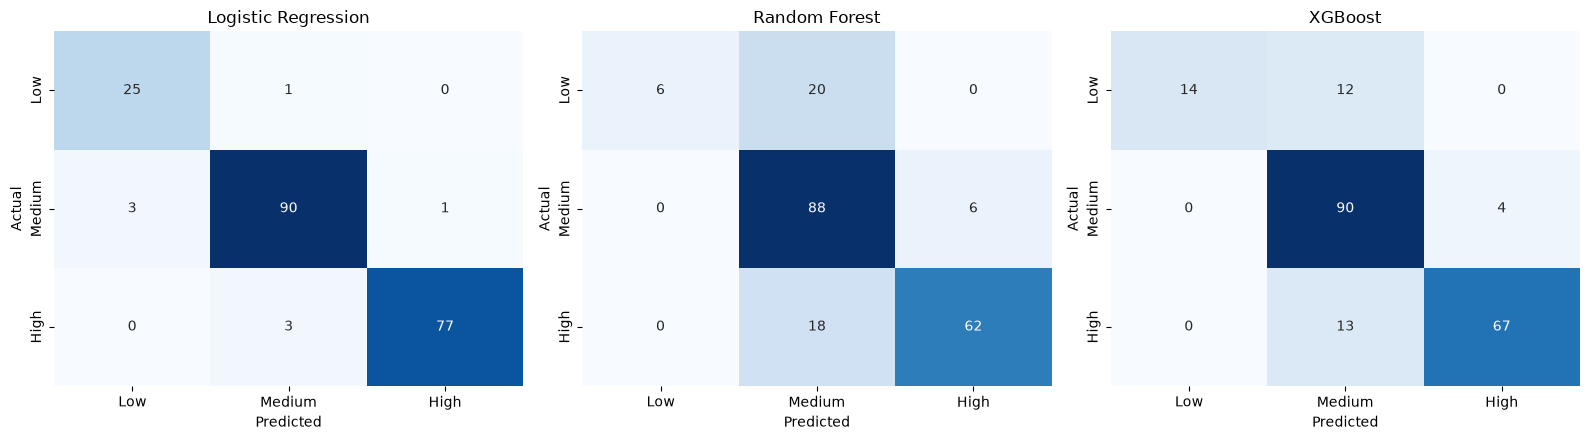

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

model_preds = {}
for ax, (name, model, uses_numeric) in zip(axes, [('Logistic Regression', lr, False),
                                                     ('Random Forest', rf, False),
                                                     ('XGBoost', xgb, True)]):
    if uses_numeric:
        preds = pd.Series(model.predict(X_test)).map(inv_risk_map).values
    else:
        preds = model.predict(X_test)
    model_preds[name] = preds
    cm = confusion_matrix(y_test, preds, labels=class_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_order,
                yticklabels=class_order, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=120)
plt.show()

In [5]:
print('Classification report - Logistic Regression\n')
print(classification_report(y_test, model_preds['Logistic Regression'], labels=class_order))

Classification report - Logistic Regression

              precision    recall  f1-score   support

         Low       0.89      0.96      0.93        26
      Medium       0.96      0.96      0.96        94
        High       0.99      0.96      0.97        80

    accuracy                           0.96       200
   macro avg       0.95      0.96      0.95       200
weighted avg       0.96      0.96      0.96       200



## Model Comparison Table

In [6]:
results_df.style.format({'Accuracy':'{:.3f}', 'Precision (macro)':'{:.3f}', 'Recall (macro)':'{:.3f}', 'F1 (macro)':'{:.3f}'})

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.960,0.946,0.960,0.953
1,XGBoost,0.855,0.909,0.778,0.816
2,Random Forest,0.780,0.870,0.647,0.671


## Best-performing model: Logistic Regression

**Justification:**
- Highest accuracy, macro-precision, macro-recall, and macro-F1 of the three models, on both
  cross-validated training folds (Task 5) and the held-out test set.
- Crucially, it also achieves the best **recall on the minority `Low` class** (see classification
  report above) — for a clinical risk tool, missing a genuinely low-risk patient is less costly than
  missing a high-risk one, but the model should still not be biased purely toward the majority classes.
- The tree ensembles (Random Forest, XGBoost) underperform here relative to a linear model. This
  matches the correlation analysis in Task 3/4: the strongest predictors (age, blood_sugar_mg_dl,
  cholesterol_mg_dl, bmi, systolic_bp) relate to disease_risk_level in an approximately linear,
  threshold-driven way, since the dataset was constructed around clinical thresholds — which favors
  Logistic Regression's linear decision boundaries over tree-based models that need more data/depth
  to approximate the same boundary.
- Logistic Regression is also the most interpretable of the three, which matters for a healthcare
  decision-support tool (Task 7 will build on this).

**Logistic Regression is carried forward as the final model for Task 7 (Explainable AI) and
Task 8 (Prototype).**

In [7]:
import joblib
joblib.dump(results_df, '../models/evaluation_results.pkl')
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.960,0.945828,0.960495,0.952685
1,XGBoost,0.855,0.908757,0.777803,0.816220
2,Random Forest,0.780,0.870059,0.647313,0.670946
